# EV Risk Scoring Model

## Section 1: Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot") 
np.random.seed(42)

risk_matrix=pd.read_excel("Week3_EV_RiskFactorMatrix_Group_B.xlsx", skiprows=3)
risk_matrix=risk_matrix.dropna(subset=["Risk Factor"])
risk_matrix.head()


,#,Risk Factor,Category,Description / Driver,"Probability\n(1=Low, 5=High)","Severity\n(1=Low, 5=High)",Risk Score\n(P × S),Risk Level,Proposed\nLoading %,Key Data Source,Underwriting Action
1,1,Thermal Runaway — NMC/NCA Chemistry,Battery,NMC/NCA cells release ~300 kJ/Ah on failure vs...,4.0,5.0,20.0,CRITICAL,30–45%,NFPA 855; NHTSA SGO 2021-01; Week 2 Memo S2,Apply NMC/NCA surcharge; require fire suppress...
2,2,Thermal Runaway — LFP Chemistry,Battery,LFP thermal onset at 270°C vs 210°C (NMC); sig...,2.0,4.0,8.0,MEDIUM,10–18%,NFPA 855; BYD Atto 3 spec sheet; Week 2 Memo S1,Base loading; LFP discount vs NMC baseline
3,3,Battery Degradation & Capacity Loss,Battery,LFP retains ~80% capacity at 150k km; NMC degr...,3.0,3.0,9.0,MEDIUM,8–15%,MIT Battery Lab 2023; Tesla Battery Report 2024,Require annual battery health cert after Year ...
4,4,Battery Management System (BMS) Failure,Battery,"BMS failure can allow overcharge, cell imbalan...",2.0,5.0,10.0,HIGH,15–25%,NHTSA complaints EV database; OEM recall notices,Exclusion clause for non-OEM BMS modifications...
5,5,Battery Flood / Water Ingress,Battery,Malaysia's monsoon season creates elevated flo...,4.0,4.0,16.0,HIGH,20–30%,PICC China flood data 2020; Malaysia flood sta...,Flood zone surcharge; require IP67/IP68 batter...


In [2]:
fleet_mix = {
    "BYD_Atto3_LFP": 0.32,
    "Tesla_M3_NMC": 0.18, # 18% Tesla Model 3 LR (NMC)
    "Tesla_M3_NCA": 0.06, # 6% Tesla Model 3 Performance (NCA)
    "Hyundai_Ioniq5": 0.12, # 12% Hyundai Ioniq 5 (NMC)
    "BMW_iX": 0.05, # 5% BMW iX (NMC)
    "Other_BEV": 0.27 # 27% other models
}

N=10000
vehicles=np.random.choice(list(fleet_mix.keys()),size=N,p=list(fleet_mix.values()))

chemistry_map = {
    "BYD_Atto3_LFP": "LFP",
    "Tesla_M3_NMC": "NMC", 
    "Tesla_M3_NCA": "NCA", 
    "Hyundai_Ioniq5": "NMC", 
    "BMW_iX": "NMC", 
    "Other_BEV": "NMC" 
}

si_map = {
    "BYD_Atto3_LFP": (130000, 160000),
    "Tesla_M3_NMC": (185000, 215000),
    "Tesla_M3_NCA": (225000, 250000),
    "Hyundai_Ioniq5":(175000, 210000),
    "BMW_iX": (440000, 550000),
    "Other_BEV": (90000, 160000)    
}

adas_map = {
    'BYD_Atto3_LFP': 'BYD_DiPilot',
    'Tesla_M3_NMC': 'Tesla_Autopilot',
    'Tesla_M3_NCA': 'Tesla_Autopilot',
    'Hyundai_Ioniq5': 'Level1',
    'BMW_iX': 'Level1',
    'Other_BEV': 'None'
}

## Section 2: Exploratory Data Analysis

In [3]:
risk_matrix["Category"].value_counts()

Category
Battery           8
ADAS              7
Repair Cost       5
Environmental     5
Residual Value    4
Infrastructure    4
Name: count, dtype: int64

In [4]:
risk_matrix["Risk Score\n(P × S)"].describe()

count    33.000000
mean     11.484848
std       4.458988
min       4.000000
25%       9.000000
50%      12.000000
75%      15.000000
max      20.000000
Name: Risk Score\n(P × S), dtype: float64

<Axes: >

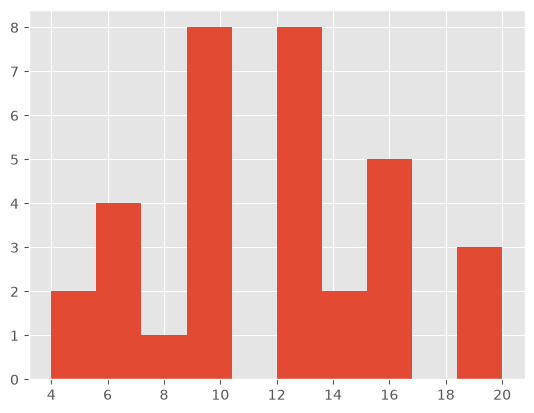

In [5]:
risk_matrix["Risk Score\n(P × S)"].hist()

## Section 3: Risk Factor Definition and Weighing

In [6]:
risk_lookup=dict(zip(risk_matrix["Risk Factor"],risk_matrix["Risk Score\n(P × S)"]))

In [7]:
df=pd.DataFrame({
    "vehicle_type":vehicles,
    "battery_chemistry":[chemistry_map[v] for v in vehicles],
    "adas_level":[adas_map[v] for v in vehicles],
    "driver_age": np.random.normal(38,10,N).clip(18,75).astype(int),
    "ev_experience_years": np.random.choice([0,1,2,3], N, p=[0.3,0.35,0.25,0.1]),
    "garaging": np.random.choice(["basement","covered","open"], N, p=[0.25,0.35,0.40]),
    "state": np.random.choice(["Selangor","KL","Johor","Penang","Other"], N, p=[0.30,0.15,0.15,0.10,0.30]),
    "annual_km": np.random.normal(18000,6000, N).clip(5000,60000),
    "sum_insured": [np.random.randint(*si_map[v]) for v in vehicles]
})
df

,vehicle_type,battery_chemistry,adas_level,driver_age,ev_experience_years,garaging,state,annual_km,sum_insured
0,Tesla_M3_NMC,NMC,Tesla_Autopilot,23,0,covered,Penang,21876.018565,214829
1,Other_BEV,NMC,None,26,0,open,Johor,26017.402202,135911
2,Other_BEV,NMC,None,41,0,open,KL,25533.216072,99428
3,Hyundai_Ioniq5,NMC,Level1,26,0,open,Other,12598.874254,202256
4,BYD_Atto3_LFP,LFP,BYD_DiPilot,49,1,covered,Penang,13527.501305,156849
...,...,...,...,...,...,...,...,...,...
9995,Other_BEV,NMC,None,37,1,open,KL,12893.104994,145943
9996,Other_BEV,NMC,None,45,1,open,Other,5157.596651,110585
9997,Other_BEV,NMC,None,47,3,basement,Selangor,29854.581943,120312
9998,Tesla_M3_NMC,NMC,Tesla_Autopilot,31,1,open,Other,7788.861218,213820


In [8]:
battery_risk = {
    "LFP": 8,
    "NMC": 20,
    "NCA": 20
}

adas_risk = {
    "None": 0,
    "Level1": 4,
    "BYD_DiPilot": 9,
    "Tesla_Autopilot": 16
}

state_risk = {
    "KL": 5,
    "Penang": 8,
    "Selangor": 10,
    "Other": 10,
    "Johor": 16
}

def km_risk(km):
    if km < 10000:
        return 4
    elif km < 20000:
        return 8
    elif km < 30000:
        return 12
    else:
        return 16

## Section 4: Risk Score Calculator

In [9]:
def calculate_ev_risk_score(row):

    score = 0

    score += battery_risk[row["battery_chemistry"]]
    score += state_risk[row["state"]]
    score += km_risk(row["annual_km"])
    score += adas_risk[row["adas_level"]]

    if row["driver_age"] < 25:
        score += 10
    elif row["driver_age"] > 55:
        score += 4
    else:
        score += 6

    if row["ev_experience_years"] == 0:
        score += 10
    elif row["ev_experience_years"] == 1:
        score += 8
    elif row["ev_experience_years"] == 2:
        score += 6
    else:
        score += 4

    return ((score-25)/63)*100

df["risk_score"]=df.apply(calculate_ev_risk_score, axis=1)
def risk_band(score):
    if score<43:
        return "low"
    elif score<6:
        return "medium"
    else:
        return "high"
    
df["risk_band"]=df["risk_score"].apply(risk_band)

## Section 5: Sensitivity Analysis

## Section 6: Synthetic Scenario Testing

In [10]:
base_freq=0.095

chem_freq = {

    'LFP': 0.85,

    'NMC': 1.00,

    'NCA': 1.00

}

garage_freq = {

    'basement': 1.10,

    'covered': 1.00,

    'open': 0.90

}

age_freq = df['driver_age'].apply(

    lambda a: 1.15 if a < 25

    else (0.95 if a > 55 else 1.00)

)

exp_freq = df['ev_experience_years'].map({

    0: 1.15,

    1: 1.08,

    2: 1.00,

    3: 0.95

})

km_freq = df['annual_km'].apply(

    lambda km: 0.90 if km < 10000

    else (1.00 if km < 20000

    else (1.10 if km < 30000

    else 1.20))

)

state_freq = {

    'KL': 0.95,

    'Penang': 1.00,

    'Selangor': 1.05,

    'Other': 1.05,

    'Johor': 1.10

}

df["claim_probability"]=((base_freq)*df["battery_chemistry"].map(chem_freq)*df["garaging"].map(garage_freq)* df['state'].map(state_freq)*age_freq.values* exp_freq.values* km_freq.values).clip(0.01, 0.40)

df["had_claim"]=np.random.binomial(1,df["claim_probability"])

df["risk_band"].value_counts()



risk_band
high    6252
low     3748
Name: count, dtype: int64

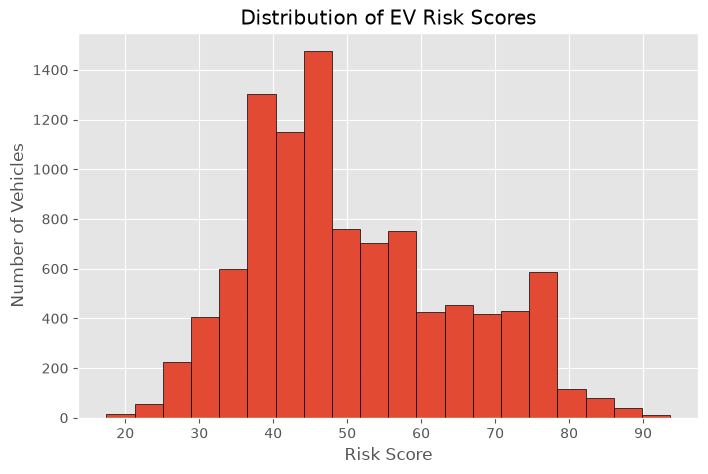

In [11]:
plt.figure(figsize=(8,5))



plt.hist(df["risk_score"], bins=20, edgecolor="black")



plt.title("Distribution of EV Risk Scores")

plt.xlabel("Risk Score")

plt.ylabel("Number of Vehicles")



plt.show()

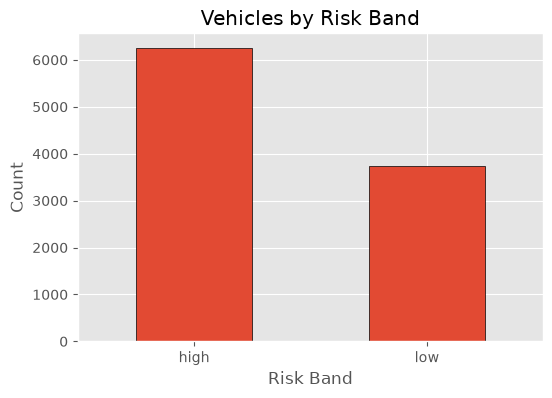

In [12]:
plt.figure(figsize=(6,4))

df["risk_band"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Vehicles by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

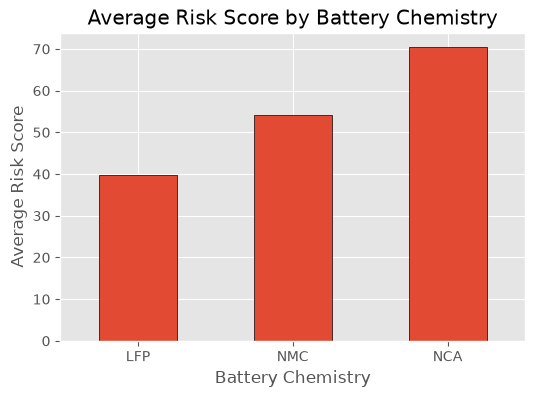

In [13]:
plt.figure(figsize=(6,4))

df.groupby("battery_chemistry")["risk_score"] \
  .mean() \
  .sort_values() \
  .plot(kind="bar", edgecolor="black")

plt.title("Average Risk Score by Battery Chemistry")
plt.xlabel("Battery Chemistry")
plt.ylabel("Average Risk Score")

plt.xticks(rotation=0)

plt.show()

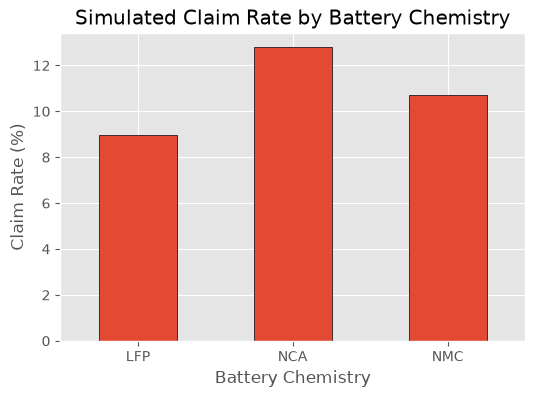

In [14]:
claim_rate = (
    df.groupby("battery_chemistry")["had_claim"]
      .mean()*100
)

plt.figure(figsize=(6,4))

claim_rate.plot(
    kind="bar",
    edgecolor="black"
)

plt.ylabel("Claim Rate (%)")
plt.xlabel("Battery Chemistry")
plt.title("Simulated Claim Rate by Battery Chemistry")

plt.xticks(rotation=0)

plt.show()

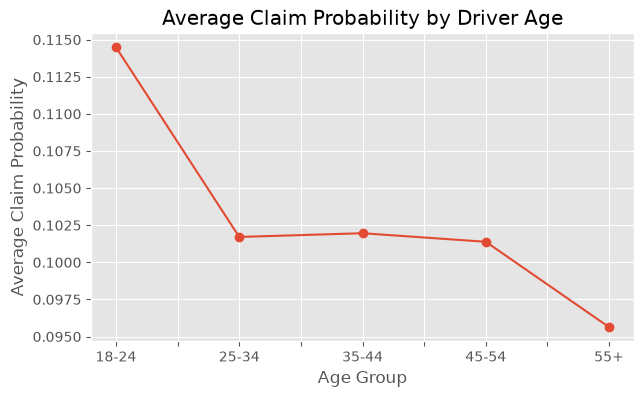

In [15]:
df["age_group"] = pd.cut(
    df["driver_age"],
    bins=[18,25,35,45,55,75],
    labels=["18-24","25-34","35-44","45-54","55+"]
)

plt.figure(figsize=(7,4))

df.groupby("age_group")["claim_probability"] \
  .mean() \
  .plot(marker="o")

plt.title("Average Claim Probability by Driver Age")
plt.xlabel("Age Group")
plt.ylabel("Average Claim Probability")

plt.grid(True)

plt.show()

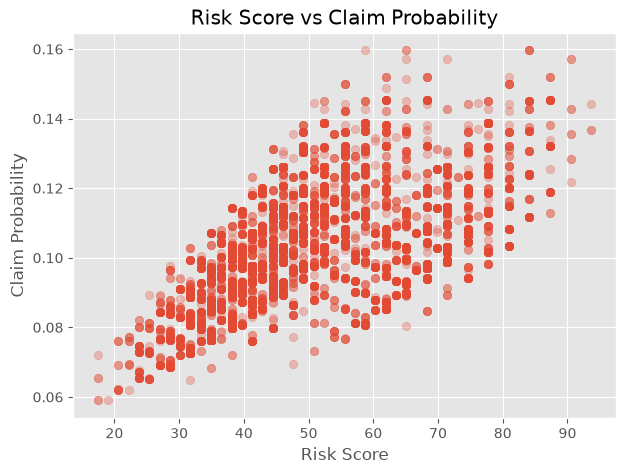

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["risk_score"],
    df["claim_probability"],
    alpha=0.3
)

plt.title("Risk Score vs Claim Probability")
plt.xlabel("Risk Score")
plt.ylabel("Claim Probability")

plt.show()

In [17]:
top10 = (
    df.nlargest(10,"risk_score")
    [["vehicle_type",
      "battery_chemistry",
      "driver_age",
      "annual_km",
      "risk_score"]]
)

top10

,vehicle_type,battery_chemistry,driver_age,annual_km,risk_score
6066,Tesla_M3_NMC,NMC,47,31229.993065,93.650794
7347,Tesla_M3_NMC,NMC,24,22518.354414,93.650794
9468,Tesla_M3_NCA,NCA,24,20414.927036,93.650794
2093,Tesla_M3_NCA,NCA,23,21948.902299,90.476190
2196,Tesla_M3_NMC,NMC,44,30775.052080,90.476190
2499,Tesla_M3_NMC,NMC,19,23950.539113,90.476190
2839,Tesla_M3_NMC,NMC,23,20034.913792,90.476190
7131,Tesla_M3_NMC,NMC,21,21018.468903,90.476190
7479,Tesla_M3_NMC,NMC,26,30811.195139,90.476190
9126,Tesla_M3_NMC,NMC,35,31346.355787,90.476190


In [18]:
print("Average Risk Score :", round(df["risk_score"].mean(),2))
print("Average Claim Probability :", round(df["claim_probability"].mean()*100,2),"%")
print("Overall Simulated Claim Rate :", round(df["had_claim"].mean()*100,2),"%")

print("\nRisk Band Distribution")
print(df["risk_band"].value_counts(normalize=True)*100)

Average Risk Score : 50.48
Average Claim Probability : 10.3 %
Overall Simulated Claim Rate : 10.27 %

Risk Band Distribution
risk_band
high    62.52
low     37.48
Name: proportion, dtype: float64


## Section 7: Bayesian Update Demonstration

## Section 8: Conclusions